In [ ]:
import shap
import pandas as pd
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score, f1_score,recall_score)
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
from random import random
warnings.filterwarnings('ignore')
pd.set_option('max_colwidth', 1000)


In [ ]:
data = pd.read_csv("/home/data.csv")
data=data.astype(bool)
data=data.fillna(0)
data.head(3)

,android.permission.GET_ACCOUNTS,com.sonyericsson.home.permission.BROADCAST_BADGE,android.permission.READ_PROFILE,android.permission.MANAGE_ACCOUNTS,android.permission.WRITE_SYNC_SETTINGS,android.permission.READ_EXTERNAL_STORAGE,android.permission.RECEIVE_SMS,com.android.launcher.permission.READ_SETTINGS,android.permission.WRITE_SETTINGS,com.google.android.providers.gsf.permission.READ_GSERVICES,...,com.android.launcher.permission.UNINSTALL_SHORTCUT,com.sec.android.iap.permission.BILLING,com.htc.launcher.permission.UPDATE_SHORTCUT,com.sec.android.provider.badge.permission.WRITE,android.permission.ACCESS_NETWORK_STATE,com.google.android.finsky.permission.BIND_GET_INSTALL_REFERRER_SERVICE,com.huawei.android.launcher.permission.READ_SETTINGS,android.permission.READ_SMS,android.permission.PROCESS_INCOMING_CALLS,Result
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29332 entries, 0 to 29331
Data columns (total 87 columns):
 #   Column                                                                         Non-Null Count  Dtype
---  ------                                                                         --------------  -----
 0   android.permission.GET_ACCOUNTS                                                29332 non-null  bool 
 1   com.sonyericsson.home.permission.BROADCAST_BADGE                               29332 non-null  bool 
 2   android.permission.READ_PROFILE                                                29332 non-null  bool 
 3   android.permission.MANAGE_ACCOUNTS                                             29332 non-null  bool 
 4   android.permission.WRITE_SYNC_SETTINGS                                         29332 non-null  bool 
 5   android.permission.READ_EXTERNAL_STORAGE                                       29332 non-null  bool 
 6   android.permission.RECEIVE_SMS        

In [ ]:
#DISTRIBUTIA DATELOR OUTPUTS/INPUTS
#Datele sunt distribuite relativ egal nu exista dezechilibru
d = {}
for i in data.columns:
    d[i] = len(data[i].unique())
pd.DataFrame(d, index=[0])


,android.permission.GET_ACCOUNTS,com.sonyericsson.home.permission.BROADCAST_BADGE,android.permission.READ_PROFILE,android.permission.MANAGE_ACCOUNTS,android.permission.WRITE_SYNC_SETTINGS,android.permission.READ_EXTERNAL_STORAGE,android.permission.RECEIVE_SMS,com.android.launcher.permission.READ_SETTINGS,android.permission.WRITE_SETTINGS,com.google.android.providers.gsf.permission.READ_GSERVICES,...,com.android.launcher.permission.UNINSTALL_SHORTCUT,com.sec.android.iap.permission.BILLING,com.htc.launcher.permission.UPDATE_SHORTCUT,com.sec.android.provider.badge.permission.WRITE,android.permission.ACCESS_NETWORK_STATE,com.google.android.finsky.permission.BIND_GET_INSTALL_REFERRER_SERVICE,com.huawei.android.launcher.permission.READ_SETTINGS,android.permission.READ_SMS,android.permission.PROCESS_INCOMING_CALLS,Result
0,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2


Result
True     14700
False    14632
Name: count, dtype: int64


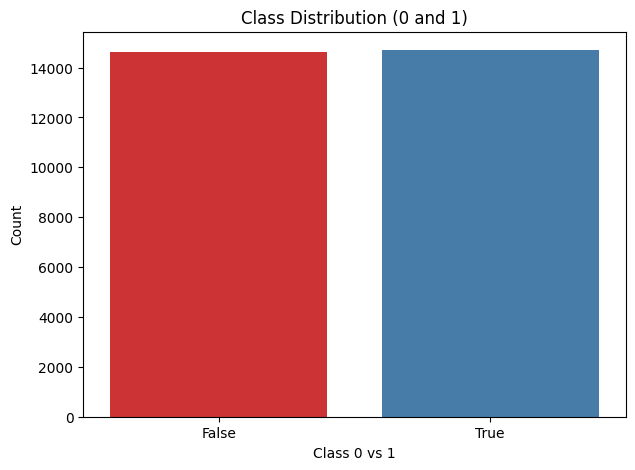

In [ ]:
print(data['Result'].value_counts())
plt.figure(figsize=(7, 5), dpi=100)
sns.countplot(x='Result', data=data, palette='Set1')
plt.title("Class Distribution (0 and 1)")
plt.ylabel("Count")
plt.xlabel("Class 0 vs 1")
plt.show()

In [ ]:
#Daca exista valori nule
pd.DataFrame(data.isnull().sum()).T

,android.permission.GET_ACCOUNTS,com.sonyericsson.home.permission.BROADCAST_BADGE,android.permission.READ_PROFILE,android.permission.MANAGE_ACCOUNTS,android.permission.WRITE_SYNC_SETTINGS,android.permission.READ_EXTERNAL_STORAGE,android.permission.RECEIVE_SMS,com.android.launcher.permission.READ_SETTINGS,android.permission.WRITE_SETTINGS,com.google.android.providers.gsf.permission.READ_GSERVICES,...,com.android.launcher.permission.UNINSTALL_SHORTCUT,com.sec.android.iap.permission.BILLING,com.htc.launcher.permission.UPDATE_SHORTCUT,com.sec.android.provider.badge.permission.WRITE,android.permission.ACCESS_NETWORK_STATE,com.google.android.finsky.permission.BIND_GET_INSTALL_REFERRER_SERVICE,com.huawei.android.launcher.permission.READ_SETTINGS,android.permission.READ_SMS,android.permission.PROCESS_INCOMING_CALLS,Result
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Separate features and target
X = data.drop(columns=['Result'])
y = data['Result']

# Split the dataset into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("MARIMI:")
print("Permisiunile de atrenare si testare(X):",X_train.shape,X_test.shape,"\nRezultatele de antrenare si testare(y):",y_train.shape,y_test.shape)

MARIMI:
Permisiunile de atrenare si testare(X): (23465, 86) (5867, 86) 
Rezultatele de antrenare si testare(y): (23465,) (5867,)


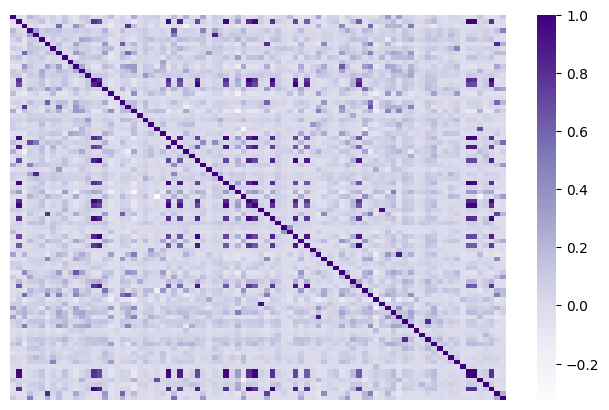

In [ ]:
# Corelarea datelor:mov inchis->datele sunt foarte corelate / mov dechis-->corelatie mica
#Diagonale implicit sunt corelate feature/feature
plt.figure(figsize=(8, 5), dpi=100)
sns.heatmap(X.corr(), cmap='Purples', xticklabels=False, yticklabels=False);


Logistic Regression --->

Accuracy: 0.964
F1-Score : 0.969

Classification Report:
               precision    recall  f1-score   support

       False       0.97      0.96      0.96      2944
        True       0.96      0.97      0.96      2923

    accuracy                           0.96      5867
   macro avg       0.96      0.96      0.96      5867
weighted avg       0.96      0.96      0.96      5867



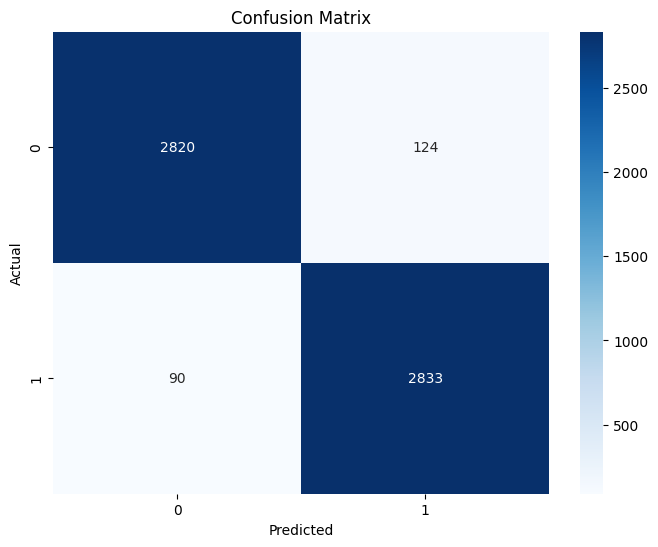

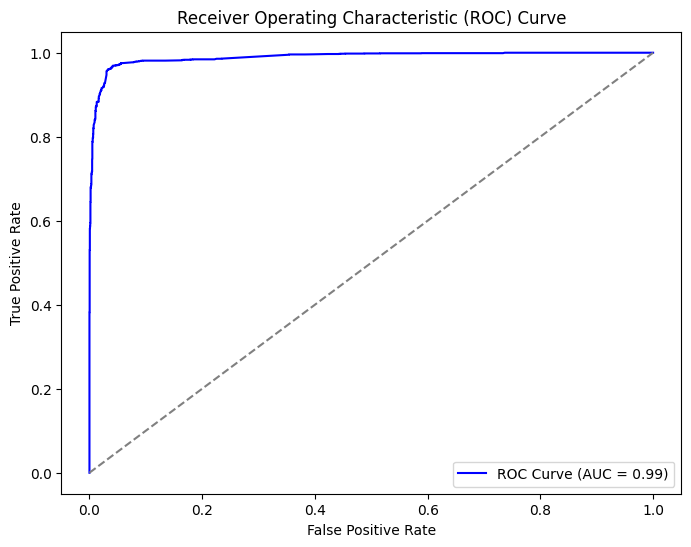

In [ ]:
# --------LOGISTIC REGRESSION---------
#Nu exista clase multinomiale deci param multi_class este nefolositor iar date sunt echilibrate fara weight class /parametrul dual nu este folosit
#dat fiind faptul ca avem de a aface cu un set de date 'larg' pe linii nu pe coloane

log_reg = LogisticRegression(max_iter=1000, random_state=0,penalty='l1',solver='liblinear',C=0.85)
#90/124 Solverul liblinear ofera cea mai buna performanta din punct de vedere al timpului(2s)+date relativ mici idk cu penalizare pe l1 (Lasso util pentru selectia de caracteristici reduce coef la 0 poate genera overfitting fara l2 ridge)
#Am adaugat de asemenea un 0.85 la C pt o generalizare(regularizare) cu 15% mai mare decat cel default sa nu fie overfit avand in vedere ca am folosit l1 ca penalizare

#log_reg = LogisticRegression(max_iter=1000, random_state=0,solver='saga',penalty='elasticnet',l1_ratio=0.875) #90/123 kindda slower
#Saga ofera cea mai buna flexibilitate si cele mai corecte rezultate dar este destul de lent(14s) cu penalizare elasticnet 0.125->l2;0.875->l1
log_reg.fit(X_train, y_train)

# Make predictions
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]  # Probability scores for ROC
print("Logistic Regression --->\n")
# Calculate metrics
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"F1-Score : {recall_score(y_test,y_pred ):.3f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred))

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

KNN MODEL --->

Accuracy: 0.967

F1-Score : 0.966

Classification Report:
               precision    recall  f1-score   support

       False       0.97      0.97      0.97      2944
        True       0.97      0.97      0.97      2923

    accuracy                           0.97      5867
   macro avg       0.97      0.97      0.97      5867
weighted avg       0.97      0.97      0.97      5867



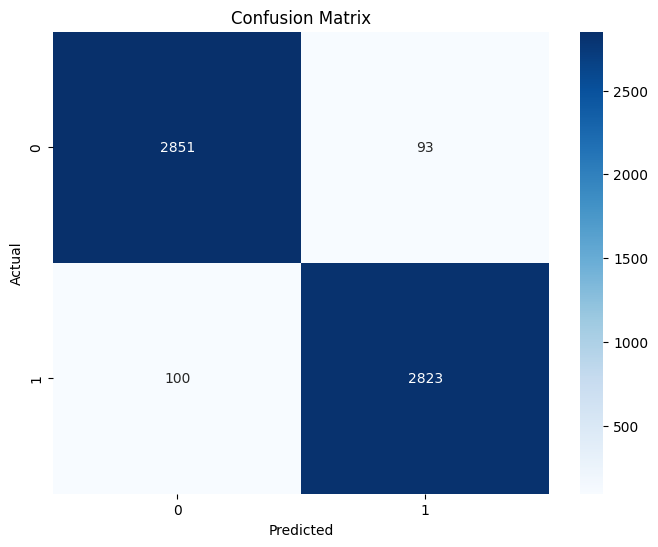

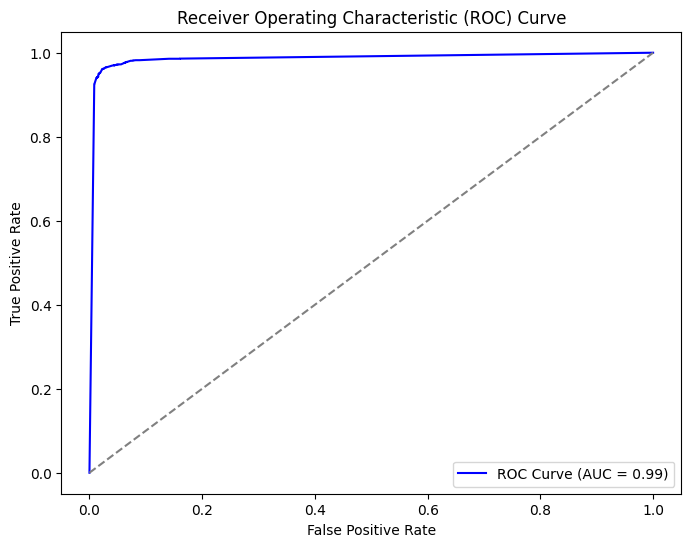

In [ ]:
# --------KNN MODEL---------
#Distanta Manhattan pentru valori cu un nr decent de 0 timp ridicat(37s) am ales selectia de distanta pt fiecare vecin in functie de fiecare data de intrare
#Distanta Manhattan pt ca e set de date cu valori binare deci trebuie calculata distanta absoluta
#valoare propriu zisa fata de Euclidian nu se schimba dar distanta manhattan e mai putin influentata de imprastirea datelor in spatiu dimensional mai mare
#ceea ce este cazul pt 86 de variabile si mai putin sensibila la outliere
knn = KNeighborsClassifier(n_neighbors=10,weights='distance',p=1)#100/93

knn.fit(X_train, y_train)

# Make predictions
y_pred = knn.predict(X_test)
y_prob = knn.predict_proba(X_test)[:, 1]


print("KNN MODEL --->\n")
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.3f}\n")
print(f"F1-Score : {recall_score(y_test,y_pred ):.3f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred))

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


PermutationExplainer explainer: 302it [00:19,  9.67it/s]                         


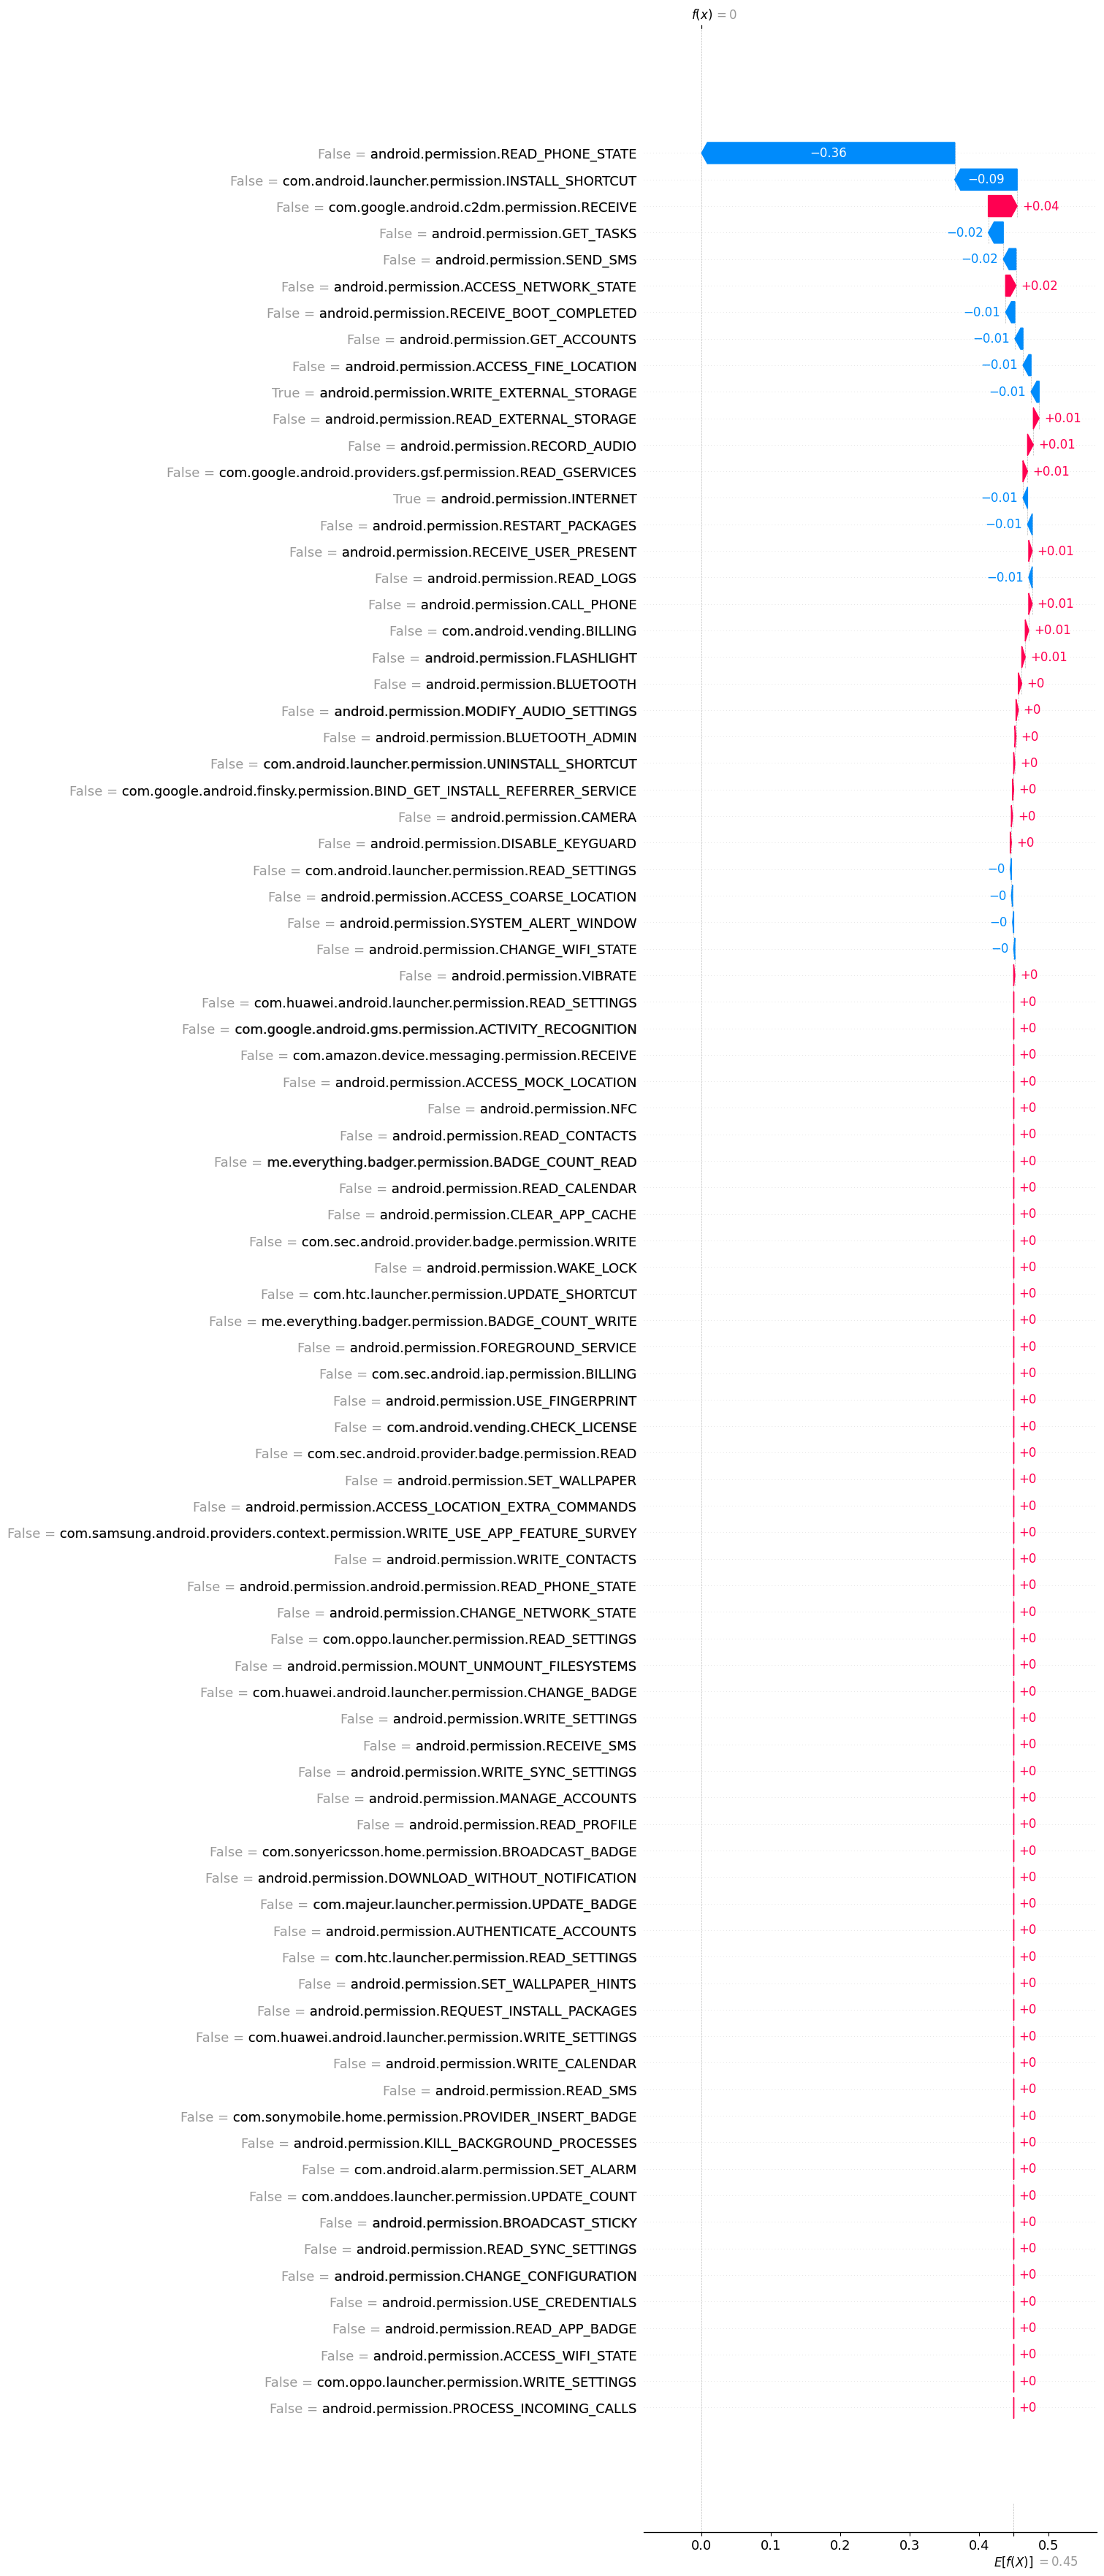

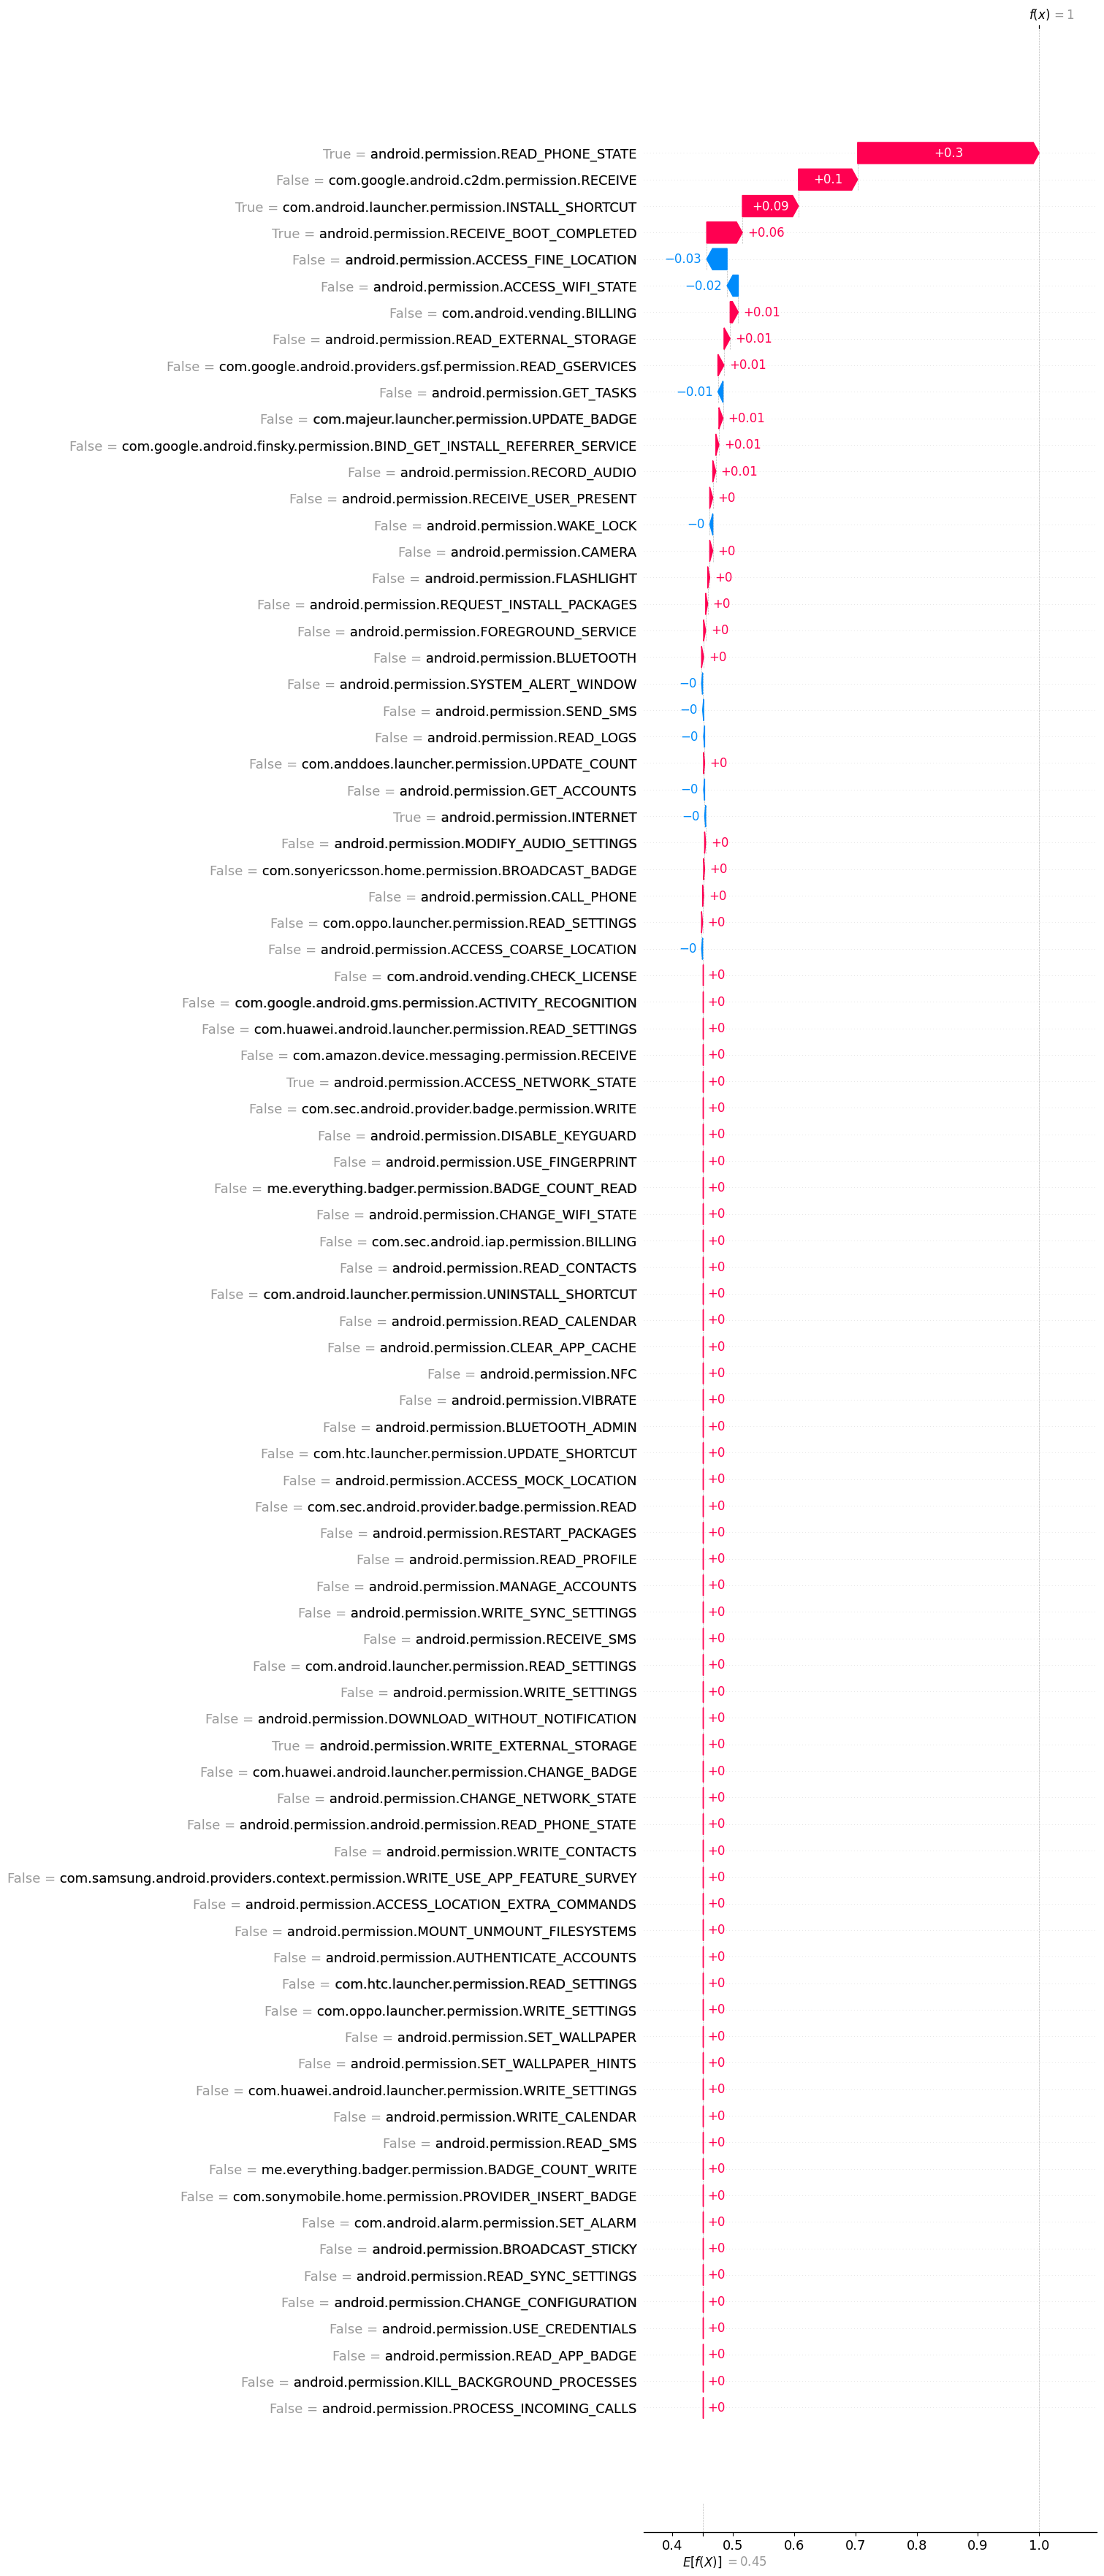

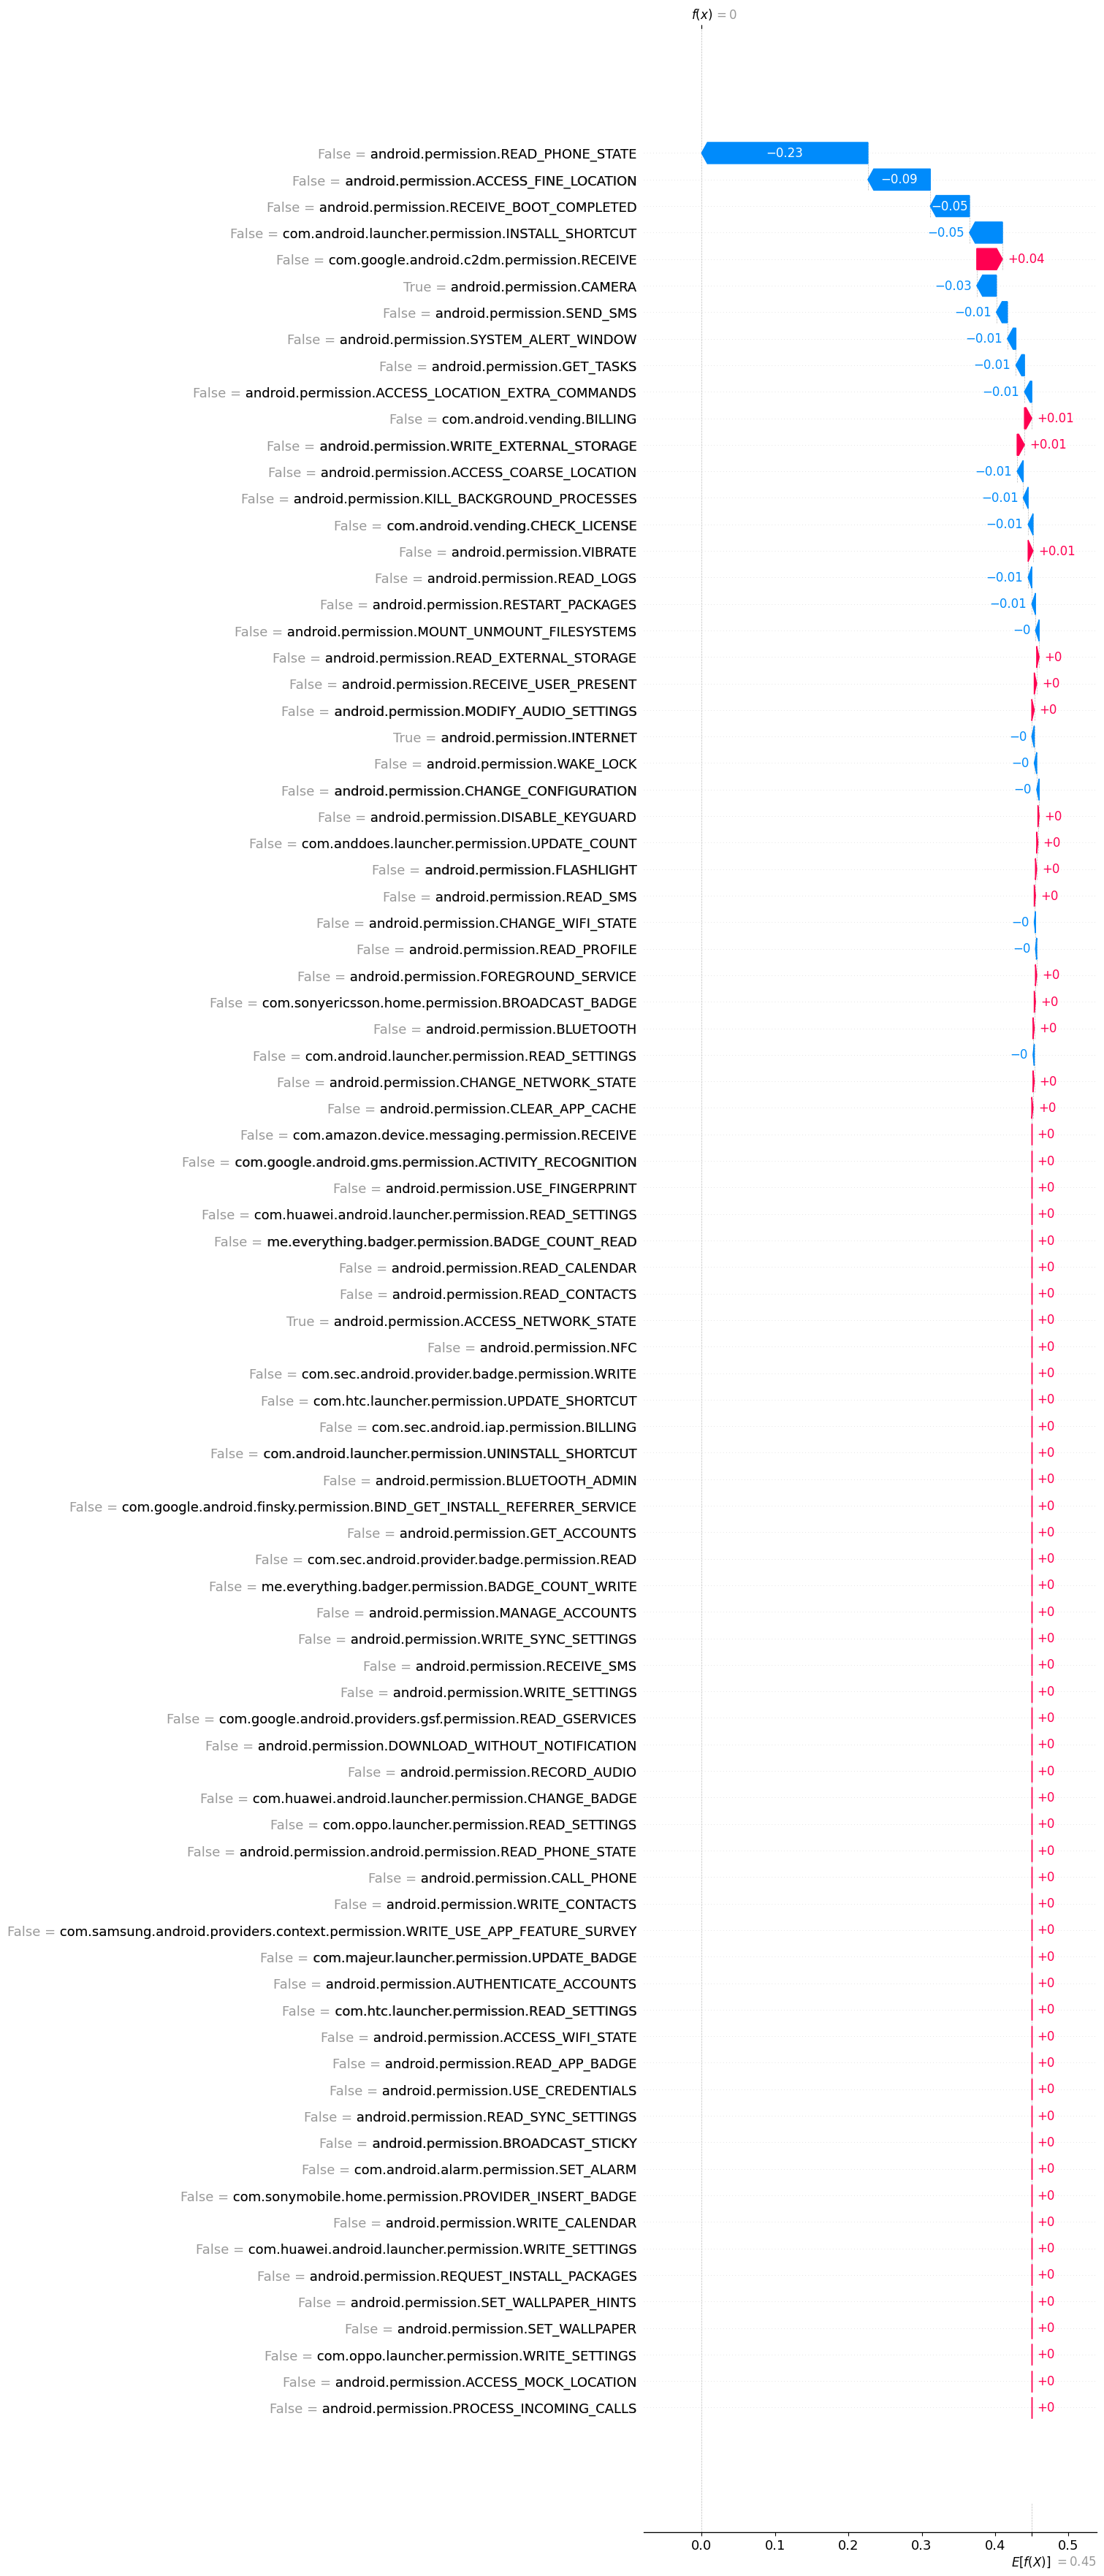

In [ ]:
xxx = X_test.reset_index(drop=True).loc[0:300, :]
explainer = shap.Explainer(log_reg.predict, xxx)
shap_values = explainer(xxx)
shap.plots.waterfall(shap_values[2], max_display=xxx.shape[1]) #valoare prezisa ca neinfectata dar infectata(FN)
shap.plots.waterfall(shap_values[4], max_display=xxx.shape[1]) #Valore prezisa ca infectata
shap.plots.waterfall(shap_values[0], max_display=xxx.shape[1]) #Valoare prezisa ca neinfectata
#Valori cu rosu insemna ca creste probabilitatea ca un telefon sa fie infectat
#iar numarul arata cat de mult influenteaza acea stare predictia de infectare media este de E(x)=0.45